In [2]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

# Task 0
Data extraction: get the data from 3 tables & combine it into single `.csv` file.
After that read this file using pandas to create Dataframe.
So it will be all joined data in 1 dataframe. Quick check - should be 74818 rows in it.

In [3]:
conn = sqlite3.connect("../db.sqlite3")
sql_query = pd.read_sql_query(
    """
    SELECT
        oi.quantity,
        oi.order_id,
        oi.product_id,
        o.datetime,
        rp.price,
        rp.name

    FROM restaurant_orderitem oi
    JOIN restaurant_order o ON oi.order_id = o.id
    JOIN restaurant_product rp ON oi.product_id = rp.id
    """, conn)

sql_query.to_csv("restaurants.csv", index=False)

df = pd.read_csv("restaurants.csv")

,quantity,order_id,product_id,datetime,price,name
0,2,1,6,2019-08-03 20:25:00,0.80,Plain Papadum
1,1,1,240,2019-08-03 20:25:00,12.95,King Prawn Balti
2,1,1,19,2019-08-03 20:25:00,2.95,Garlic Naan
3,1,1,36,2019-08-03 20:25:00,3.95,Mushroom Rice
4,1,1,111,2019-08-03 20:25:00,8.95,Paneer Tikka Masala
...,...,...,...,...,...,...
74813,2,3255,247,2016-05-18 18:53:00,17.95,House Red wine 75cl
74814,2,12905,247,2016-05-14 19:28:00,17.95,House Red wine 75cl
74815,2,3272,247,2016-05-10 13:18:00,17.95,House Red wine 75cl
74816,1,11404,248,2016-04-07 19:04:00,17.95,House white wine 75cl


# Task 1
Get Top 10 most popular products in restaurant sold by Quantity.
Count how many times each product was sold and create a pie chart with percentage of popularity (by quantity) for top 10 of them.

Example:

![pie chart](../demo/pie.png)

([<matplotlib.patches.Wedge at 0x11399aba0>,
 [Text(0.7334749827461747, 0.8197648746350986, 'Plain Papadum'),
  Text(-0.6335860435101969, 0.8992044959124121, 'Pilau Rice'),
  Text(-1.0979774543958056, 0.06667465514351695, 'Plain Naan'),
  Text(-0.9110263351151625, -0.6164665576709215, 'Garlic Naan'),
  Text(-0.507757498330542, -0.9757983003106276, 'Plain Rice'),
  Text(-0.031485821083686395, -1.0995492908781699, 'Onion Bhajee'),
  Text(0.41435169385136295, -1.0189762871639882, 'Mango Chutney'),
  Text(0.7730271064920154, -0.7825784897558725, 'Chicken Tikka Masala'),
  Text(0.9936146914233249, -0.4719426289155611, 'Chapati'),
  Text(1.088407439873117, -0.15927725772641707, 'Mint Sauce')],
 [Text(0.4000772633160953, 0.4471444770736901, '26.77%'),
  Text(-0.34559238736919823, 0.49047517958858833, '16.01%'),
  Text(-0.598896793306803, 0.0363679937146456, '12.53%'),
  Text(-0.49692345551736133, -0.33625448600232083, '8.34%'),
  Text(-0.27695863545302285, -0.5322536183512514, '7.45%'),
  Tex

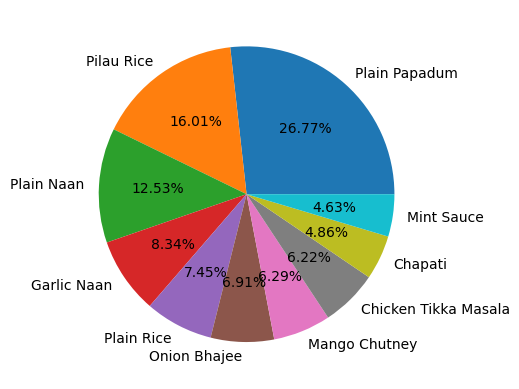

In [4]:
result = df.groupby("name")["quantity"].sum().sort_values(ascending=False).head(10)

plt.pie(result, labels=result.index, autopct='%1.2f%%')

# Task 2
Calculate `Item Price` (Product Price * Quantity) for each Order Item in dataframe.
And Make the same Top 10 pie chart, but this time by `Item Price`. So this chart should describe not the most popular products by quantity, but which products (top 10) make the most money for restaurant. It should be also with percentage.

([<matplotlib.patches.Wedge at 0x113968e10>,
 [Text(0.9387328640434534, 0.5733939395954369, 'Chicken Tikka Masala'),
  Text(0.009681695464081614, 1.0999573922534187, 'Pilau Rice'),
  Text(-0.771643639043815, 0.783942660099078, 'Plain Naan'),
  Text(-1.084408839305786, 0.18454665869497136, 'Korma'),
  Text(-1.0109681717938293, -0.4335243425920194, 'Bombay Aloo'),
  Text(-0.6451951389172755, -0.8909114617724467, 'Onion Bhajee'),
  Text(-0.10380115442942602, -1.095091466654324, 'Butter Chicken'),
  Text(0.4397334903786818, -1.0082829252939782, 'Garlic Naan'),
  Text(0.858677328043968, -0.6875123608367139, 'Korma - Chicken'),
  Text(1.0742924872946902, -0.23642261258641892, 'Plain Rice')],
 [Text(0.5120361076600654, 0.3127603306884201, '17.45%'),
  Text(0.005280924798589971, 0.5999767594109555, '14.81%'),
  Text(-0.42089653038753544, 0.4276050873267698, '10.22%'),
  Text(-0.5914957305304286, 0.10066181383362073, '9.67%'),
  Text(-0.551437184614816, -0.23646782323201054, '8.59%'),
  Text(-0

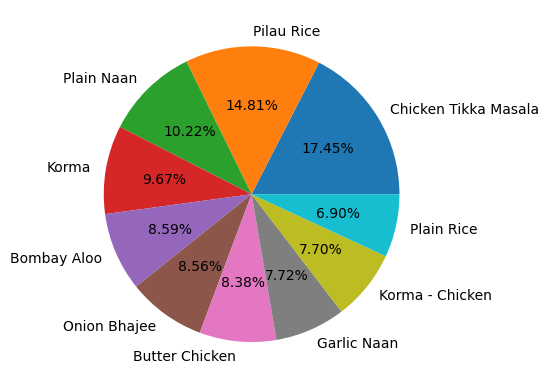

In [5]:
result = (
    df.assign(total=df["quantity"] * df["price"])
      .groupby("name")["total"]
      .sum()
      .sort_values(ascending=False).head(10)
)
plt.pie(result, labels=result.index, autopct='%1.2f%%')

# Task 3
Calculate `Order Hour` based on `Order Datetime`, which will tell about the specific our the order was created (from 0 to 23). Using `Order Hour` create a bar chart, which will tell the total restaurant income based on the hour order was created. So on x-axis - it will be values from 0 to 23 (hours), on y-axis - it will be the total sum of order prices, which were sold on that hour.

Example:

![bar chart](../demo/bar.png)

([<matplotlib.axis.XTick at 0x123ec0050>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23')])

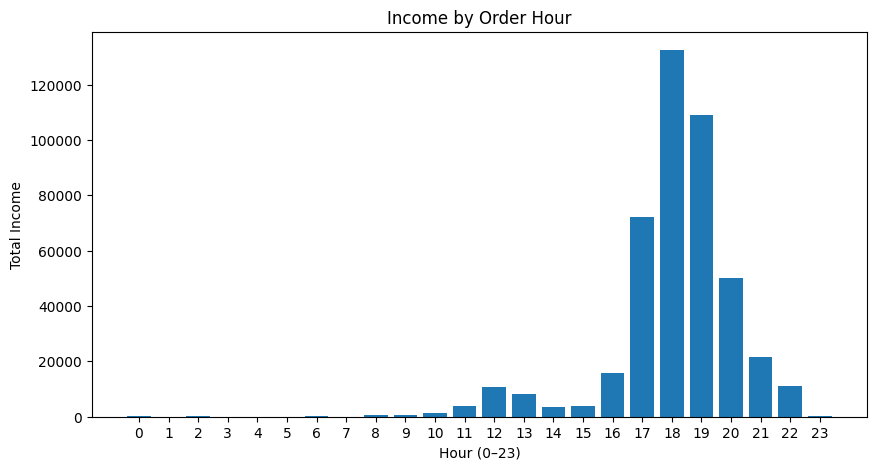

In [22]:
df["datetime"] = pd.to_datetime(df["datetime"])

df["Order Hour"] = df["datetime"].dt.hour

hourly_income = (
    df.assign(total_income=df["quantity"] * df["price"])
    .groupby("Order Hour")["total_income"]
      .sum()
      .reindex(range(24), fill_value=0)
)

plt.figure(figsize=(10,5))
plt.bar(hourly_income.index, hourly_income.values)

plt.xlabel("Hour (0–23)")
plt.ylabel("Total Income")
plt.title("Income by Order Hour")
plt.xticks(range(24))


# Task 4
Make similar bar chart, but right now with `Order Day Of The Week` (from Monday to Sunday), and also analyze total restaurant income by each day of the week.

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Monday'),
  Text(1, 0, 'Tuesday'),
  Text(2, 0, 'Wednesday'),
  Text(3, 0, 'Thursday'),
  Text(4, 0, 'Friday'),
  Text(5, 0, 'Saturday'),
  Text(6, 0, 'Sunday')])

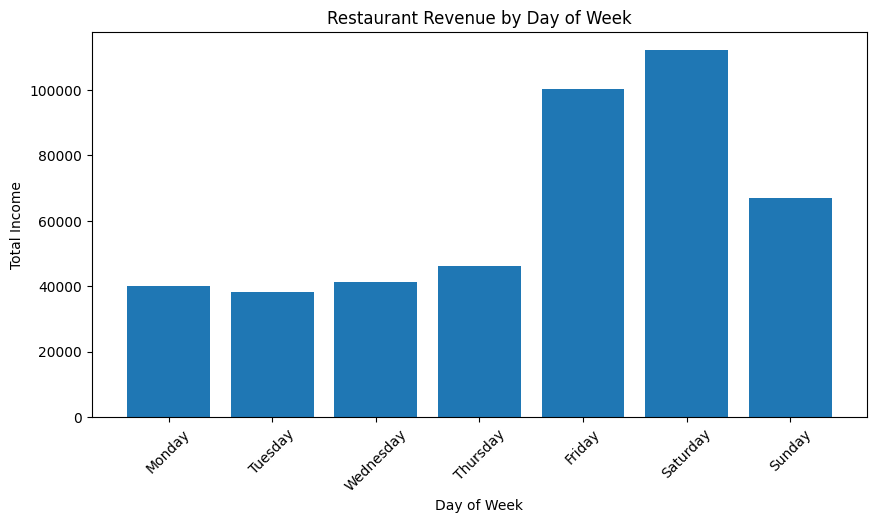

In [23]:
df["datetime"] = pd.to_datetime(df["datetime"])

df["Order Day Of The Week"] = df["datetime"].dt.day_name()

days = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

daily_income = (
    df.assign(total_income=df["quantity"] * df["price"])
    .groupby("Order Day Of The Week")["total_income"]
      .sum()
      .reindex(days, fill_value=0)
)


plt.figure(figsize=(10,5))
plt.bar(daily_income.index, daily_income.values)

plt.xlabel("Day of Week")
plt.ylabel("Total Income")
plt.title("Restaurant Revenue by Day of Week")
plt.xticks(rotation=45)